In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Download S&P 500 data
spx = pd.read_csv('spx_data.csv', index_col=0, parse_dates=True)

# Calculate log returns
spx_returns = np.log(spx['Adj Close']).diff().dropna()

# Fit ARMA(1,1) model
model_arma11 = ARIMA(spx_returns, order=(1, 0, 1)).fit()

# Print model summary
print("ARMA(1,1) Model Summary:")
print(model_arma11.summary())

# Get parameters
const = model_arma11.params['const']
ar1 = model_arma11.params['ar.L1']

# Calculate unconditional mean
uncond_mean = const / (1 - ar1)

# Get covariance matrix of parameters
cov_matrix = model_arma11.cov_params()

# Calculate standard error of unconditional mean using Delta method
# Partial derivatives of mean with respect to parameters
d_const = 1 / (1 - ar1)
d_ar = const / (1 - ar1)**2

# Variance of unconditional mean
var_mean = (d_const**2 * cov_matrix.loc['const', 'const'] + 
            d_ar**2 * cov_matrix.loc['ar.L1', 'ar.L1'] +
            2 * d_const * d_ar * cov_matrix.loc['const', 'ar.L1'])

# Standard error
se_mean = np.sqrt(var_mean)

print("\nUnconditional Mean Analysis:")
print(f"Estimated Mean: {uncond_mean:.6f}")
print(f"Standard Error: {se_mean:.6f}")
print(f"95% CI: [{uncond_mean - 1.96*se_mean:.6f}, {uncond_mean + 1.96*se_mean:.6f}]")





/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARMA(1,1) Model Summary:
                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 6032
Model:                 ARIMA(1, 0, 1)   Log Likelihood               18087.020
Date:                Fri, 14 Feb 2025   AIC                         -36166.040
Time:                        12:40:39   BIC                         -36139.221
Sample:                             0   HQIC                        -36156.729
                               - 6032                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.690      0.091   -3.99e-05       0.001
ar.L1         -0.0129      0.048     -0.266      0.790      -0.108       0.082
ma.L1         -0.0922      

In [2]:
# Define range of p and q values to test
p_values = range(0, 5)
q_values = range(0, 5)

# Create DataFrame to store results
results = pd.DataFrame(columns=['p', 'q', 'AIC', 'BIC'])

# Fit ARMA models for different p,q combinations
for p in p_values:
    for q in q_values:
        try:
            # Fit ARMA(p,q) model
            model = ARIMA(spx_returns, order=(p, 0, q))
            fitted = model.fit()
            
            # Store results
            results = pd.concat([results, pd.DataFrame({
                'p': [p],
                'q': [q],
                'AIC': [fitted.aic],
                'BIC': [fitted.bic]
            })])
            
        except:
            continue

# Display results
print("ARMA Model Results:")
print(results)


# Sort results by AIC and BIC
best_aic = results.sort_values('AIC').iloc[0]
best_bic = results.sort_values('BIC').iloc[0]

print("\nBest model by AIC:")
print(f"ARMA({int(best_aic['p'])},{int(best_aic['q'])}) with AIC = {best_aic['AIC']:.4f}")

print("\nBest model by BIC:") 
print(f"ARMA({int(best_bic['p'])},{int(best_bic['q'])}) with BIC = {best_bic['BIC']:.4f}")

# Fit and print summary of best AIC model
best_aic_model = ARIMA(spx_returns, order=(int(best_aic['p']), 0, int(best_aic['q']))).fit()
print("\nBest AIC Model Summary:")
print(best_aic_model.summary())

# Fit and print summary of best BIC model
if (best_aic['p'] != best_bic['p']) or (best_aic['q'] != best_bic['q']):
    best_bic_model = ARIMA(spx_returns, order=(int(best_bic['p']), 0, int(best_bic['q']))).fit()
    print("\nBest BIC Model Summary:")
    print(best_bic_model.summary())





/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored

ARMA Model Results:
   p  q           AIC           BIC
0  0  0 -36103.885295 -36090.475628
0  0  1 -36168.023165 -36147.908663
0  0  2 -36166.028093 -36139.208757
0  0  3 -36164.116027 -36130.591858
0  0  4 -36169.497528 -36129.268525
0  1  0 -36167.437767 -36147.323265
0  1  1 -36166.040270 -36139.220934
0  1  2 -36164.028266 -36130.504096
0  1  3 -36163.011002 -36122.781998
0  1  4 -36166.377573 -36119.443735
0  2  0 -36166.157318 -36139.337982
0  2  1 -36163.936944 -36130.412775
0  2  2 -36162.216692 -36121.987689
0  2  3 -36162.086297 -36115.152459
0  2  4 -36163.760858 -36110.122187
0  3  0 -36165.058611 -36131.534441
0  3  1 -36162.835353 -36122.606350
0  3  2 -36160.824486 -36113.890649
0  3  3 -36161.888343 -36108.249672
0  3  4 -36163.033100 -36102.689595
0  4  0 -36167.530175 -36127.301172
0  4  1 -36165.892403 -36118.958566
0  4  2 -36163.846836 -36110.208165
0  4  3 -36161.910115 -36101.566610
0  4  4 -36160.615475 -36093.567136

Best model by AIC:
ARMA(0,4) with AIC = -36

/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Best AIC Model Summary:
                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 6032
Model:                 ARIMA(0, 0, 4)   Log Likelihood               18090.749
Date:                Fri, 14 Feb 2025   AIC                         -36169.498
Time:                        12:41:41   BIC                         -36129.269
Sample:                             0   HQIC                        -36155.531
                               - 6032                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.652      0.099    -4.6e-05       0.001
ma.L1         -0.1038      0.007    -15.492      0.000      -0.117      -0.091
ma.L2         -0.0010      

/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Best BIC Model Summary:
                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 6032
Model:                 ARIMA(0, 0, 1)   Log Likelihood               18087.012
Date:                Fri, 14 Feb 2025   AIC                         -36168.023
Time:                        12:41:41   BIC                         -36147.909
Sample:                             0   HQIC                        -36161.040
                               - 6032                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.724      0.085   -3.42e-05       0.001
ma.L1         -0.1051      0.006    -16.204      0.000      -0.118      -0.092
sigma2         0.0001   1.1

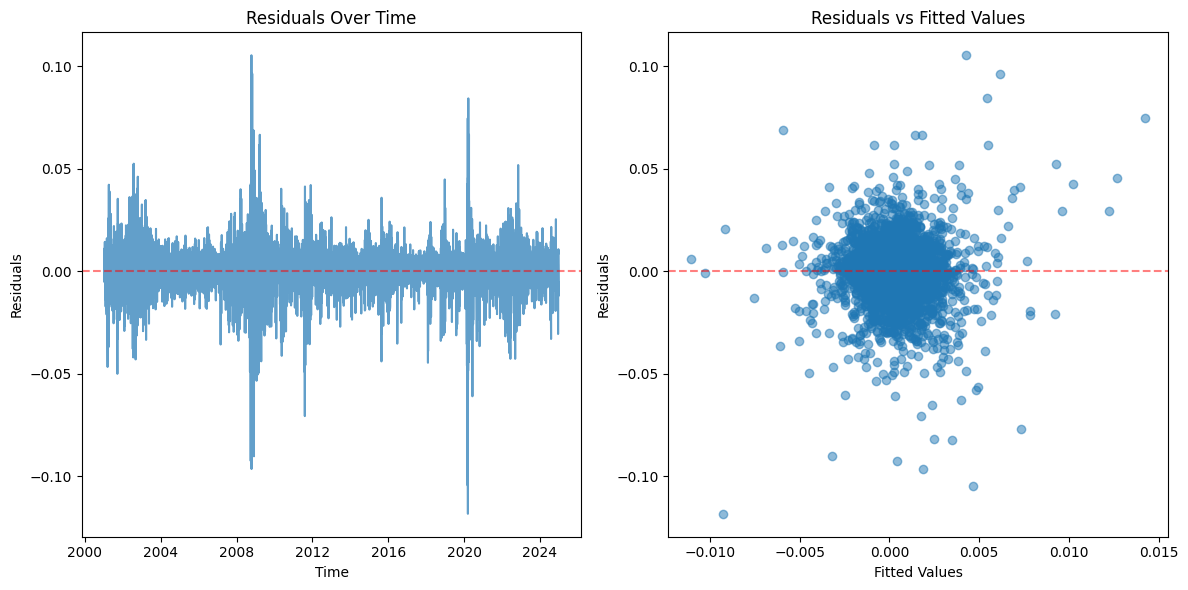

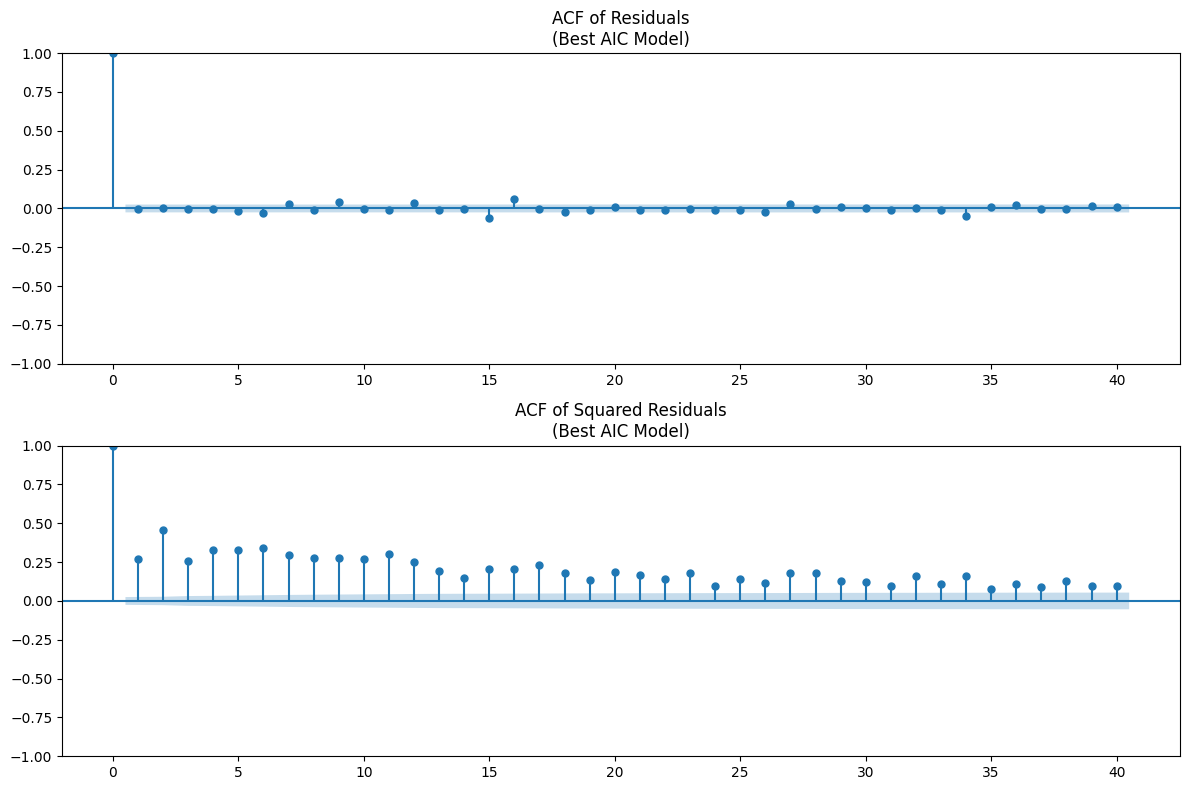


Jarque-Bera Test Results (Best AIC Model):
Statistic: 26788.8836
p-value: 0.0000

Ljung-Box Test Results (Best AIC Model):
For residuals:
For returns:
Lag 10: statistic = 25.4637, p-value = 0.0001
Lag 15: statistic = 54.3955, p-value = 0.0000
Lag 20: statistic = 83.7020, p-value = 0.0000

For absolute returns:
Lag 10: statistic = 6638.2974, p-value = 0.0000
Lag 15: statistic = 8873.2914, p-value = 0.0000
Lag 20: statistic = 10656.5945, p-value = 0.0000

For squared returns:
Lag 10: statistic = 6010.4082, p-value = 0.0000
Lag 15: statistic = 7573.3978, p-value = 0.0000
Lag 20: statistic = 8653.2084, p-value = 0.0000


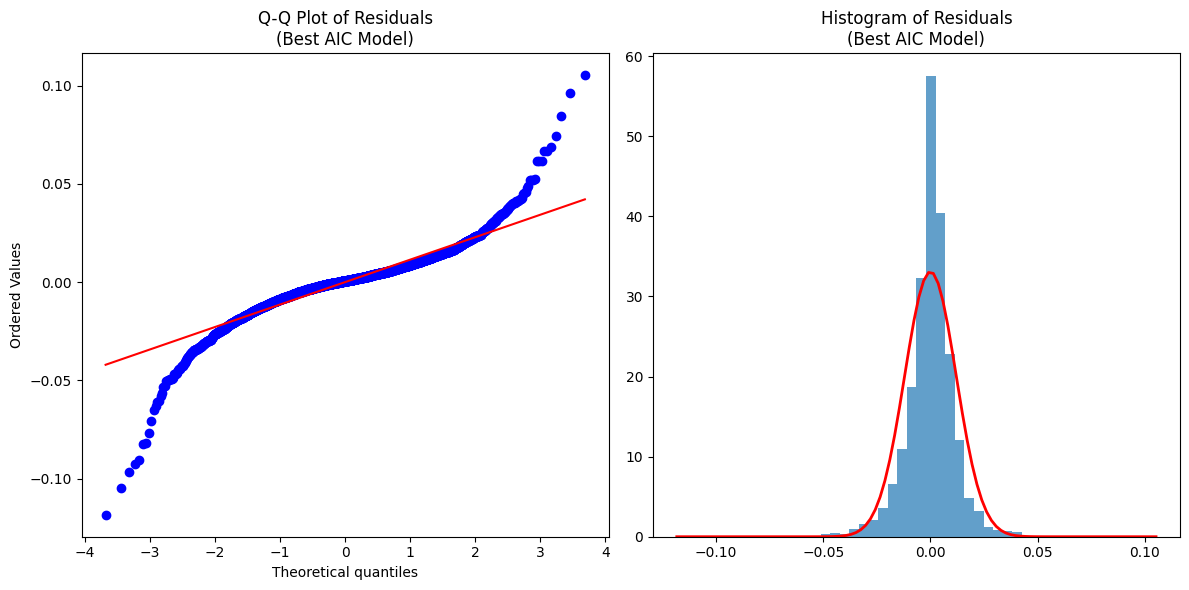

In [4]:
# Get residuals from best AIC model
residuals_aic = best_aic_model.resid

# Get fitted values
fitted_values_aic = best_aic_model.fittedvalues

# Create figure with 2 subplots
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot residuals over time
ax1.plot(residuals_aic, alpha=0.7)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax1.set_title('Residuals Over Time')
ax1.set_xlabel('Time')
ax1.set_ylabel('Residuals')

# Plot residuals vs fitted values
ax2.scatter(fitted_values_aic, residuals_aic, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_title('Residuals vs Fitted Values')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
plt.tight_layout()
plt.savefig('residuals_vs_fitted_values_best_aic_model.pdf')
plt.show()


# Plot ACF of residuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

import statsmodels.api as smapi
# ACF plot for residuals
smapi.graphics.tsa.plot_acf(residuals_aic, lags=40, ax=ax1)
ax1.set_title("ACF of Residuals\n(Best AIC Model)")

# ACF plot for squared residuals 
import statsmodels.api as smapi
smapi.graphics.tsa.plot_acf(residuals_aic**2, lags=40, ax=ax2)
ax2.set_title("ACF of Squared Residuals\n(Best AIC Model)")

plt.tight_layout()
plt.savefig('acf_residuals_best_aic_model.pdf')
plt.show()

# Jarque-Bera test
import scipy.stats as stats
jb_stat_aic, jb_pvalue_aic = stats.jarque_bera(residuals_aic)
print("\nJarque-Bera Test Results (Best AIC Model):")
print(f"Statistic: {jb_stat_aic:.4f}")
print(f"p-value: {jb_pvalue_aic:.4f}")

# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
lags = [10, 15, 20]
n_params = 5  # constant + 4 MA parameters for best AIC model
print("\nLjung-Box Test Results (Best AIC Model):")
print("For residuals:")
# Returns - adjust df for parameter estimation
print("For returns:")
for lag in lags:
    lb_test = acorr_ljungbox(residuals_aic, lags=[lag], return_df=True)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-n_params)
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

# Absolute Returns - adjust df for parameter estimation
print("\nFor absolute returns:")
for lag in lags:
    lb_test = acorr_ljungbox(np.abs(residuals_aic), lags=[lag], return_df=True)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-n_params)
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

# Squared Returns - adjust df for parameter estimation
print("\nFor squared returns:")
for lag in lags:
    lb_test = acorr_ljungbox(residuals_aic**2, lags=[lag], return_df=True)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-n_params)
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")
    

# QQ plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# QQ plot for residuals
stats.probplot(residuals_aic, dist="norm", plot=ax1)
ax1.set_title("Q-Q Plot of Residuals\n(Best AIC Model)")

# Histogram for residuals
ax2.hist(residuals_aic, bins=50, density=True, alpha=0.7)
x = np.linspace(min(residuals_aic), max(residuals_aic), 100)
ax2.plot(x, stats.norm.pdf(x, np.mean(residuals_aic), np.std(residuals_aic)), 'r-', lw=2)
ax2.set_title("Histogram of Residuals\n(Best AIC Model)")

plt.tight_layout()
plt.savefig('qq_residuals_best_aic_model.pdf')
plt.show()

First few rows of the earnings data:
      FPEDATS   IBM   JNJ   MRK
0   9/30/1984  0.65  0.05  0.05
1  12/31/1984  0.89  0.04  0.04
2   3/31/1985  0.40  0.06  0.05
3   6/30/1985  0.57  0.05  0.05
4   9/30/1985  0.60  0.05  0.05

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   FPEDATS  115 non-null    object 
 1   IBM      115 non-null    float64
 2   JNJ      115 non-null    float64
 3   MRK      115 non-null    float64
dtypes: float64(3), object(1)
memory usage: 3.7+ KB
None


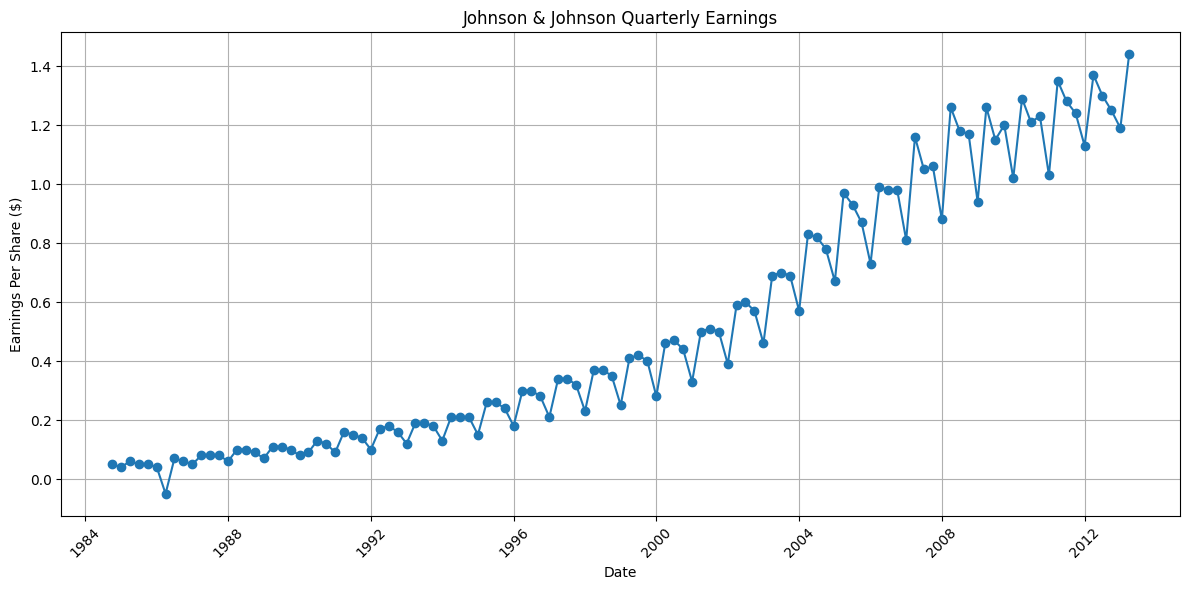

/Users/gongiuzhang/.local/lib/python3.8/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['disp']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.50568D+00    |proj g|=  1.88140D+01

At iterate    5    f= -1.58540D+00    |proj g|=  1.73510D-01

At iterate   10    f= -1.59368D+00    |proj g|=  3.95449D+00

At iterate   15    f= -1.82196D+00    |proj g|=  4.00081D+00

At iterate   20    f= -1.83759D+00    |proj g|=  4.11366D-01

At iterate   25    f= -1.89652D+00    |proj g|=  1.84354D-01

At iterate   30    f= -1.89703D+00    |proj g|=  1.64117D-01

At iterate   35    f= -1.89706D+00    |proj g|=  9.36812D-02

At iterate   40    f= -1.89707D+00    |proj g|=  2.68539D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg 


 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.


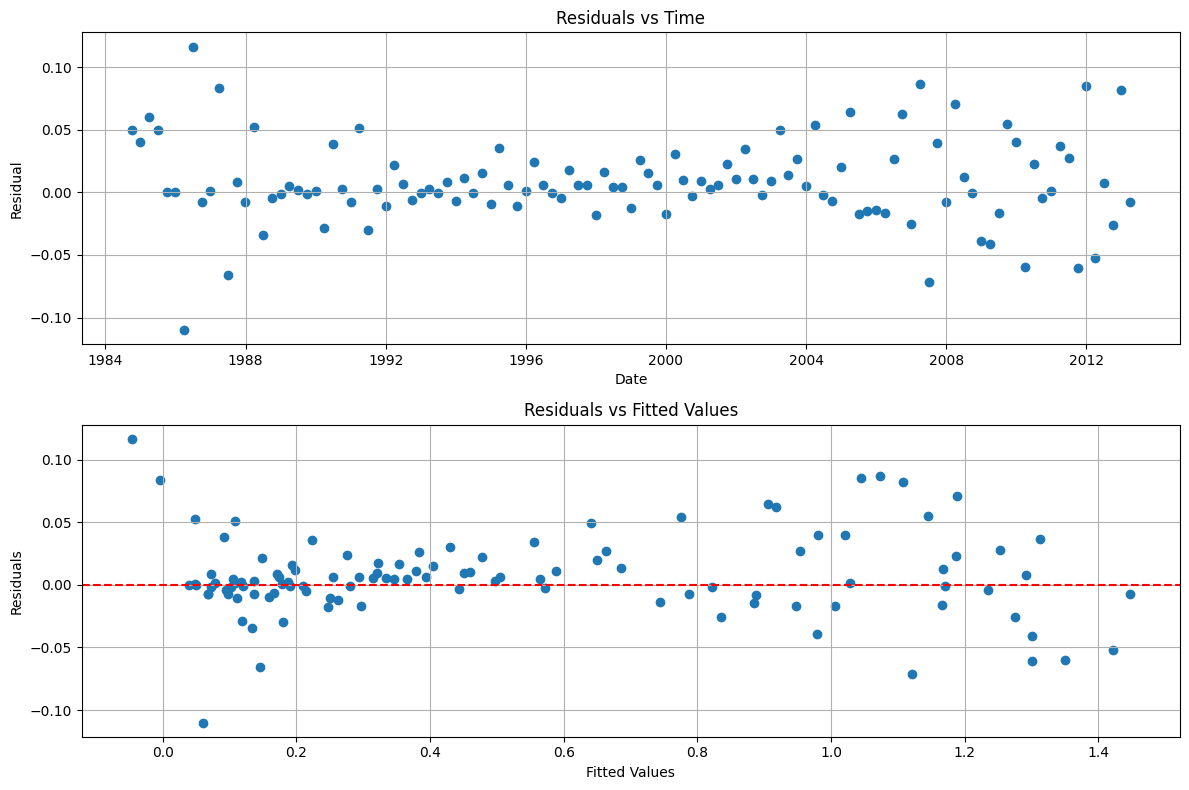

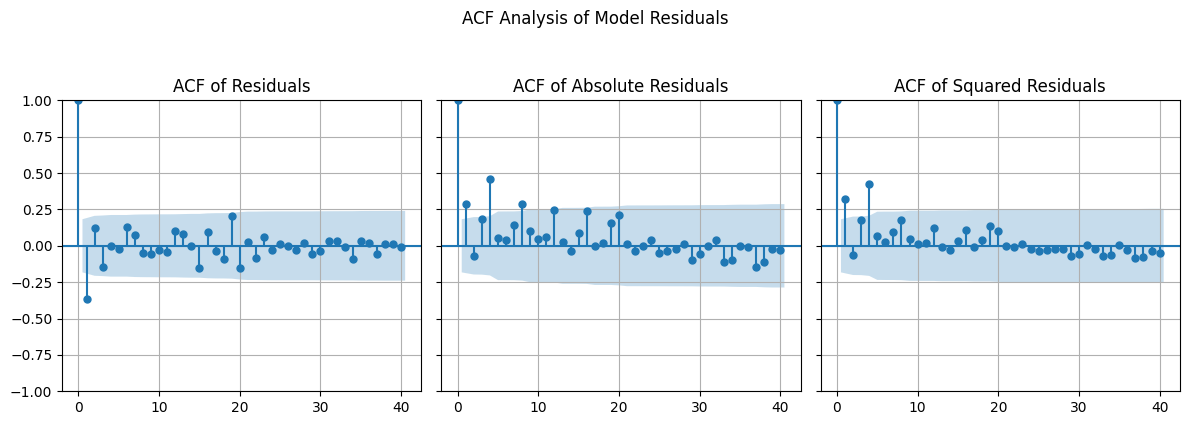

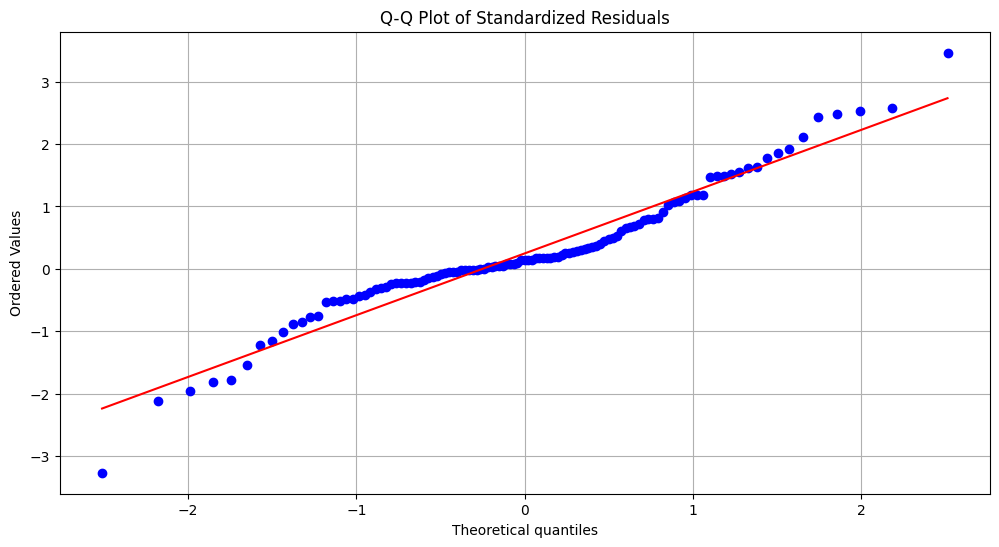


Ljung-Box Test Results:

For residuals:
Lag 10: statistic = 24.0607, p-value = 0.0022
Lag 15: statistic = 29.6714, p-value = 0.0053
Lag 20: statistic = 41.4760, p-value = 0.0013

For absolute residuals:
Lag 10: statistic = 54.9417, p-value = 0.0000
Lag 15: statistic = 64.7628, p-value = 0.0000
Lag 20: statistic = 82.3944, p-value = 0.0000

For squared residuals:
Lag 10: statistic = 44.9642, p-value = 0.0000
Lag 15: statistic = 47.1785, p-value = 0.0000
Lag 20: statistic = 53.2538, p-value = 0.0000

Jarque-Bera Test Results:
Statistic: 13.9346
p-value: 0.0009


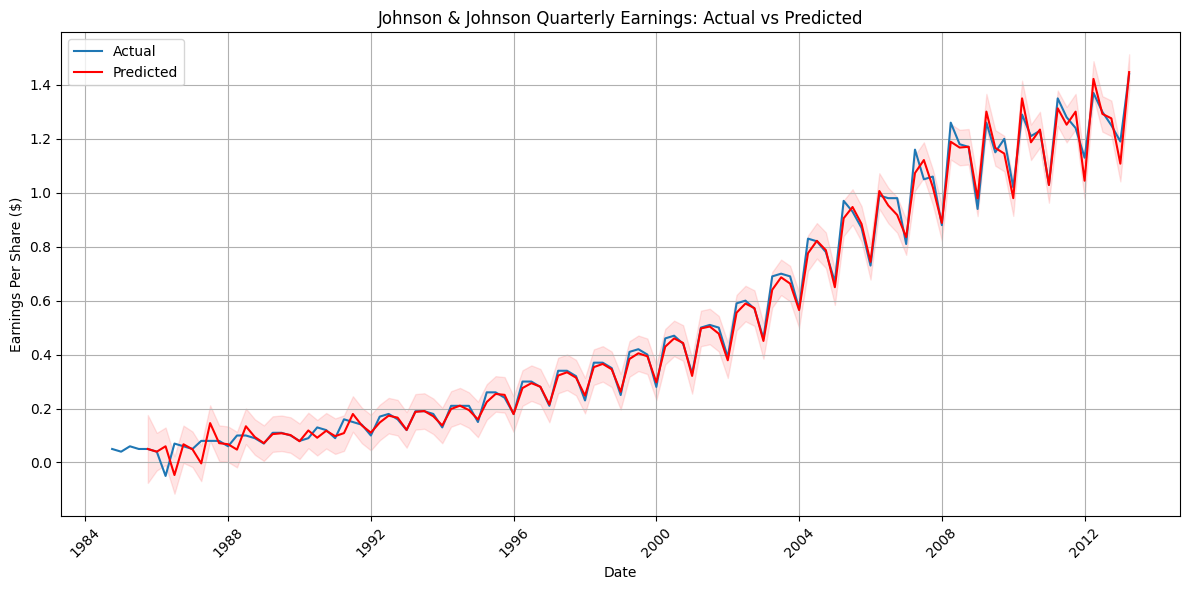


Model Summary:
                                     SARIMAX Results                                     
Dep. Variable:                               JNJ   No. Observations:                  115
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 4)   Log Likelihood                 218.163
Date:                           Fri, 14 Feb 2025   AIC                           -430.326
Time:                                   12:42:22   BIC                           -422.197
Sample:                                        0   HQIC                          -427.028
                                           - 115                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8958      0.039     22.946      0.000       0.819       0.972
ar.S.L4       -0.3413      

In [5]:
# Import earnings data
import pandas as pd

# Read the eps data
eps = pd.read_csv('eps.csv')

# Display first few rows and basic info
print("First few rows of the earnings data:")
print(eps.head())
print("\nDataset info:")
print(eps.info())

# Convert FPEDATS to datetime format
eps['FPEDATS'] = pd.to_datetime(eps['FPEDATS'], format='%m/%d/%Y')


# Plot JNJ earnings
plt.figure(figsize=(12, 6))
plt.plot(eps['FPEDATS'].values, eps['JNJ'].values, marker='o')
plt.title('Johnson & Johnson Quarterly Earnings')
plt.xlabel('Date') 
plt.ylabel('Earnings Per Share ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('jnj_earnings.pdf')
plt.show()

# Fit seasonal ARIMA model to JNJ earnings data
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set up the model - using SARIMA(1,0,0)(1,1,0,4) since we have quarterly data
# This means:
# - Non-seasonal part: AR(1), no differencing, no MA terms
# - Seasonal part: SAR(1), 1 seasonal difference, no SMA terms, period=4 (quarterly)
model = SARIMAX(eps['JNJ'], 
                order=(1,0,0),
                seasonal_order=(1,1,0,4), disp=False)

# Fit the model
results = model.fit()
# Generate predictions

predictions = results.get_prediction(start=eps.index[4])
predictions_mean = predictions.predicted_mean

# Print model summary
print("\nModel Summary:")
print(results.summary())

# Get residuals
residuals = results.resid
standardized_residuals = residuals / np.sqrt(results.params['sigma2'])

# Plot residuals
plt.figure(figsize=(12, 8))

# Residuals vs Time
plt.subplot(2,1,1)
plt.scatter(eps['FPEDATS'].values, residuals.values)
plt.title('Residuals vs Time')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)

# Residuals vs Fitted
plt.subplot(2,1,2)
plt.scatter(predictions_mean.values, residuals[4:].values)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_vs_fitted_values_jnj_earnings.pdf')
plt.show()

# ACF plots of residuals, absolute residuals, and squared residuals
from statsmodels.graphics.tsaplots import plot_acf
# Create a figure with 1x3 subplots sharing the same x and y axes
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# Original residuals
plot_acf(residuals, lags=40, alpha=0.05, ax=ax1)
ax1.set_title('ACF of Residuals')
ax1.grid(True)

# Absolute residuals 
plot_acf(np.abs(residuals), lags=40, alpha=0.05, ax=ax2)
ax2.set_title('ACF of Absolute Residuals')
ax2.grid(True)

# Squared residuals
plot_acf(residuals**2, lags=40, alpha=0.05, ax=ax3)
ax3.set_title('ACF of Squared Residuals')
ax3.grid(True)

plt.suptitle('ACF Analysis of Model Residuals', y=1.05)
plt.tight_layout()
plt.savefig('acf_residuals_jnj_earnings.pdf')
plt.show()

# QQ plot
from scipy import stats
plt.figure(figsize=(12, 6))
stats.probplot(standardized_residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Standardized Residuals")
plt.grid(True)
plt.savefig('qq_residuals_jnj_earnings.pdf')
plt.show()

# Ljung-Box test
import statsmodels.stats.diagnostic as sm
print("\nLjung-Box Test Results:")
lags = [10, 15, 20]
print("\nFor residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(residuals, lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-2) # Adjust df for AR(1) + constant = 2 parameters
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

print("\nFor absolute residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(np.abs(residuals), lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-2) # Adjust df for AR(1) + constant = 2 parameters
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

print("\nFor squared residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(residuals**2, lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-2) # Adjust df for AR(1) + constant = 2 parameters
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

# Jarque-Bera test for normality
jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print("\nJarque-Bera Test Results:")
print(f"Statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.4f}")

# Calculate confidence intervals
predictions_ci = predictions.conf_int(alpha=0.05)  # 95% confidence interval

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(eps['FPEDATS'].values, eps['JNJ'].values, label='Actual')
plt.plot(eps['FPEDATS'][4:].values, predictions_mean.values, color='red', label='Predicted')
plt.fill_between(eps['FPEDATS'][4:].values,
                predictions_ci.iloc[:,0],
                predictions_ci.iloc[:,1],
                color='red', alpha=0.1)

plt.title('Johnson & Johnson Quarterly Earnings: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Earnings Per Share ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('jnj_earnings_predictions.pdf')
plt.show()

# Print model summary
print("\nModel Summary:")
print(results.summary())





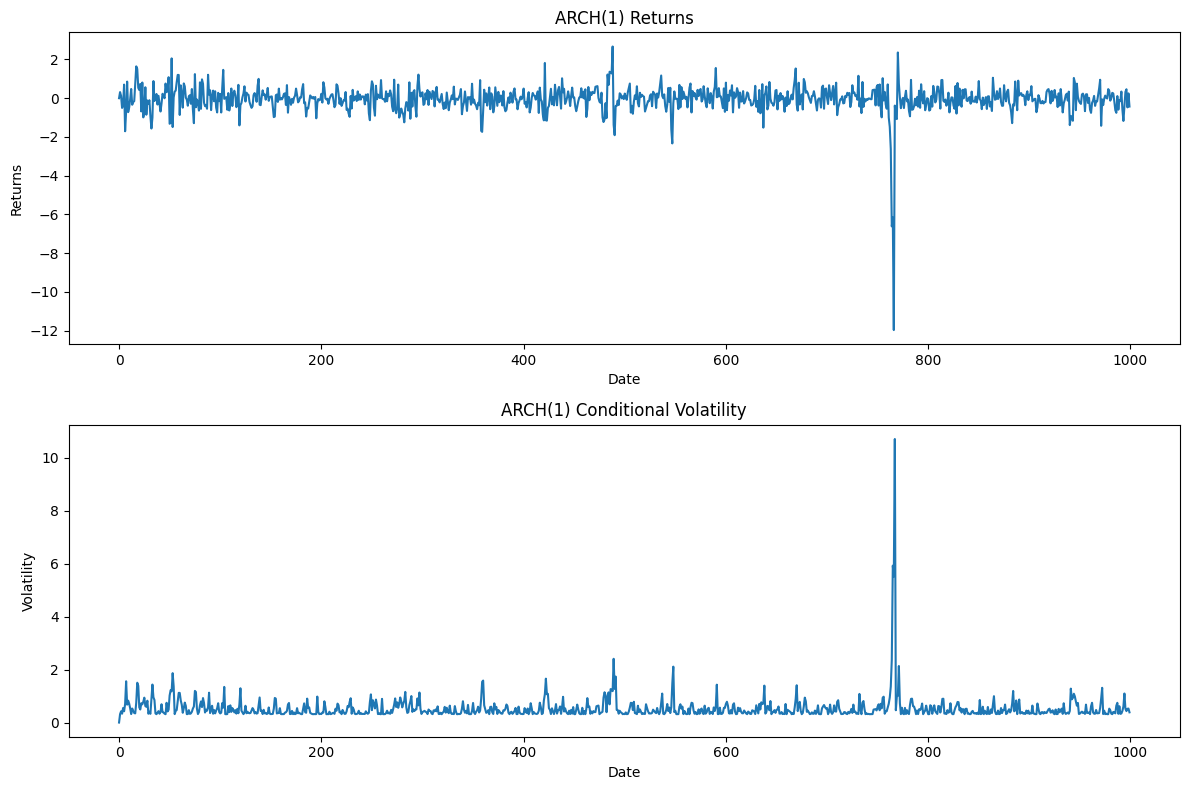

In [6]:
# Generate ARCH(1) process
np.random.seed(123)
T = 1000  # Length of time series
alpha0 = 0.1  # Constant term
alpha1 = 0.8  # ARCH parameter
Z = np.random.standard_normal(T)  # Random innovations

# Initialize arrays
X = np.zeros(T)  # Returns
sigma2 = np.zeros(T)  # Conditional variances

# Generate the process
for t in range(1,T):
    sigma2[t] = alpha0 + alpha1 * X[t-1]**2
    X[t] = Z[t] * np.sqrt(sigma2[t])

# Plot the results
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot returns
ax1.plot(X)
ax1.set_title('ARCH(1) Returns')
ax1.set_xlabel('Date')
ax1.set_ylabel('Returns')

# Plot conditional volatility
ax2.plot(np.sqrt(sigma2))
ax2.set_title('ARCH(1) Conditional Volatility')
ax2.set_xlabel('Date')
ax2.set_ylabel('Volatility')

plt.tight_layout()
plt.savefig('arch1_process.pdf')
plt.show()


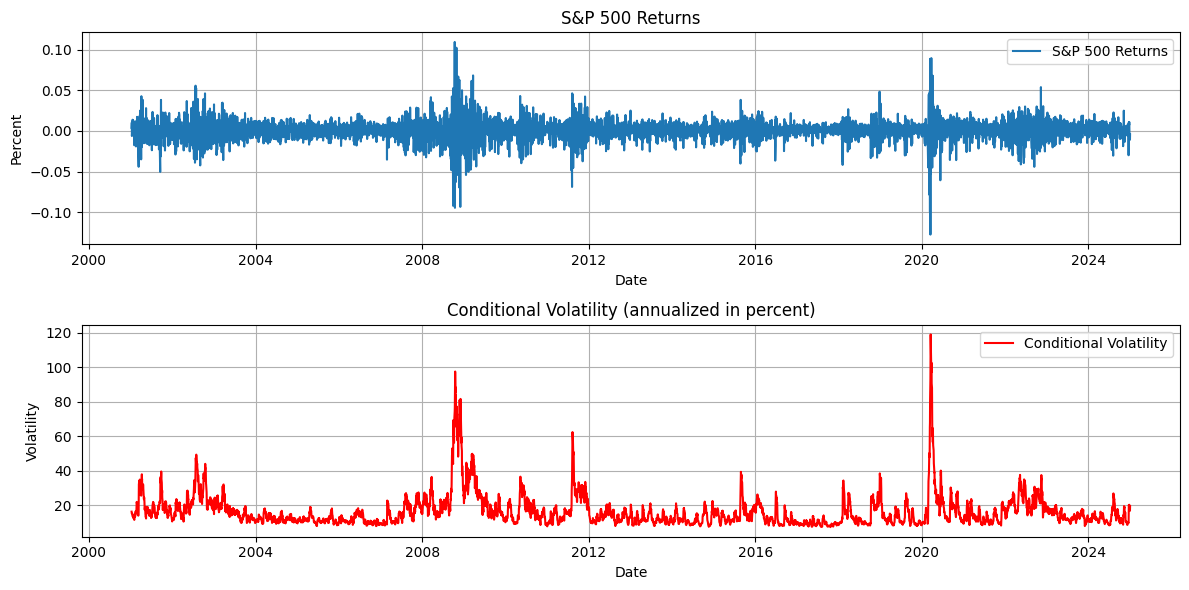

                           AR - ARCH Model Results                            
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -8207.74
Distribution:                  Normal   AIC:                           16439.5
Method:            Maximum Likelihood   BIC:                           16519.9
                                        No. Observations:                 6032
Date:                Fri, Feb 14 2025   Df Residuals:                     6031
Time:                        12:42:42   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const          0.0630  1.022e-02      6.161  7.249e-10 [4.

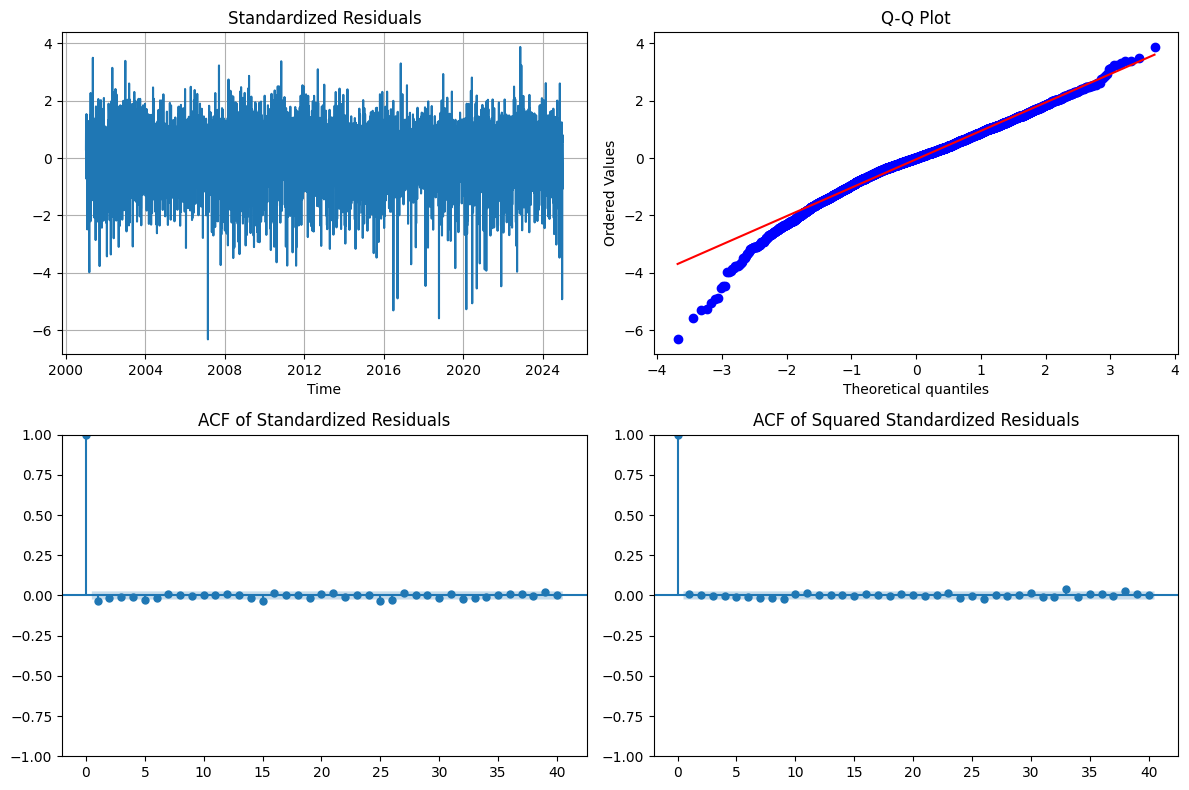


Ljung-Box Test Results:

For residuals:
Lag 15: statistic = 27.3612, p-value = 0.0000
Lag 20: statistic = 31.3198, p-value = 0.0001
Lag 30: statistic = 47.2357, p-value = 0.0002

For absolute residuals:
Lag 15: statistic = 16.1660, p-value = 0.0010
Lag 20: statistic = 25.8465, p-value = 0.0011
Lag 30: statistic = 43.8958, p-value = 0.0006

For squared residuals:
Lag 15: statistic = 9.7770, p-value = 0.0206
Lag 20: statistic = 11.2897, p-value = 0.1858
Lag 30: statistic = 19.1572, p-value = 0.3822

Jarque-Bera Test for Normality:
Statistic = 948.1496
P-value = 0.0000

Descriptive Statistics of Standardized Residuals:
Mean: -0.0447
Std Dev: 0.9990
Skewness: -0.5158
Kurtosis: 1.6457


In [7]:
# Fit AR(0)-ARCH(1) model using arch package
from arch import arch_model
import scipy.stats as stats

# Fit the model
# Filter data from 2020 to 2024
scale_factor = 100
p = 10
model = arch_model(spx_returns*scale_factor, mean='AR', lags=0, vol='ARCH', p=p)
results = model.fit(disp='off')

# Plot returns and conditional volatility in two panels
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Plot returns
ax1.plot(spx_returns, label='S&P 500 Returns')
ax1.set_title('S&P 500 Returns')
ax1.set_xlabel('Date')
ax1.set_ylabel('Percent')
ax1.grid(True)
ax1.legend()

# Plot conditional volatility
ax2.plot(results.conditional_volatility/scale_factor*np.sqrt(252)*100, label='Conditional Volatility', color='red')
ax2.set_title('Conditional Volatility (annualized in percent)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Volatility')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig(f'ar0_arch{p}_spx.pdf')
plt.show()

# Print model summary
print(results.summary())


# Perform diagnostic tests on the AR(1)-ARCH(1) model residuals
standardized_residuals = results.std_resid

# Create figure with 4 subplots for diagnostic plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized residuals
ax1.plot(standardized_residuals)
ax1.set_title('Standardized Residuals')
ax1.set_xlabel('Time')
ax1.grid(True)

# Plot 2: QQ plot
stats.probplot(standardized_residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot')

# Plot 3: ACF of standardized residuals
import statsmodels.api as smapi
smapi.graphics.tsa.plot_acf(standardized_residuals, lags=40, ax=ax3)
ax3.set_title('ACF of Standardized Residuals')

# Plot 4: ACF of squared standardized residuals
smapi.graphics.tsa.plot_acf(standardized_residuals**2, lags=40, ax=ax4)
ax4.set_title('ACF of Squared Standardized Residuals')

plt.tight_layout()
plt.savefig('ar0_arch{p}_diagnostics.pdf')
plt.show()

# Perform Ljung-Box test on standardized residuals and squared standardized residuals
import statsmodels.stats.diagnostic as sm
lags = [15, 20, 30]
print("\nLjung-Box Test Results:")
print("\nFor residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(standardized_residuals, lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-p-2)
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

print("\nFor absolute residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(np.abs(standardized_residuals), lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-p-2) # 
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

print("\nFor squared residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(standardized_residuals**2, lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-p-2) # 
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

# Perform Jarque-Bera test for normality
jb_stat, jb_pvalue = stats.jarque_bera(standardized_residuals)
print("\nJarque-Bera Test for Normality:")
print("="*80)
print(f"Statistic = {jb_stat:.4f}")
print(f"P-value = {jb_pvalue:.4f}")

# Calculate and print descriptive statistics
print("\nDescriptive Statistics of Standardized Residuals:")
print("="*80)
print(f"Mean: {np.mean(standardized_residuals):.4f}")
print(f"Std Dev: {np.std(standardized_residuals):.4f}")
print(f"Skewness: {stats.skew(standardized_residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(standardized_residuals):.4f}")




Gaussian AR(0) GARCH(1,1) Model Results:
                           AR - GARCH Model Results                           
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8202.17
Distribution:                  Normal   AIC:                           16412.3
Method:            Maximum Likelihood   BIC:                           16439.2
                                        No. Observations:                 6032
Date:                Fri, Feb 14 2025   Df Residuals:                     6031
Time:                        12:49:39   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const          0

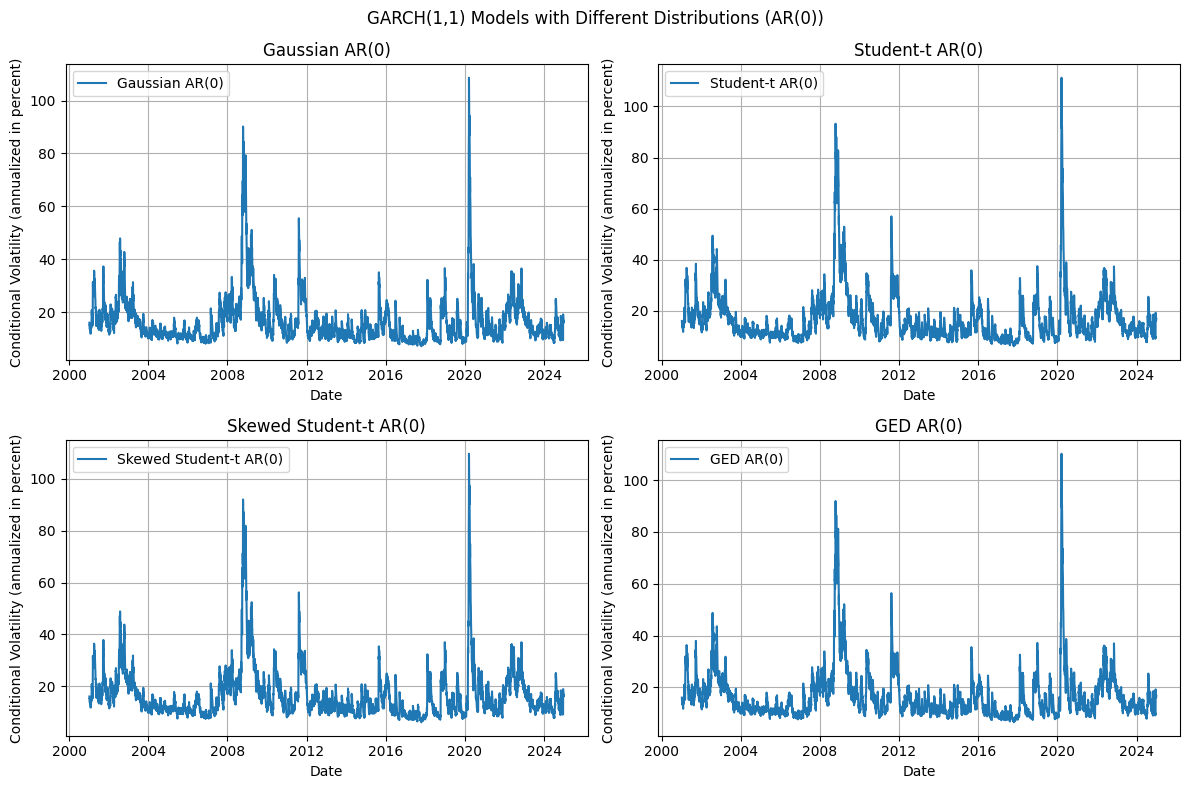

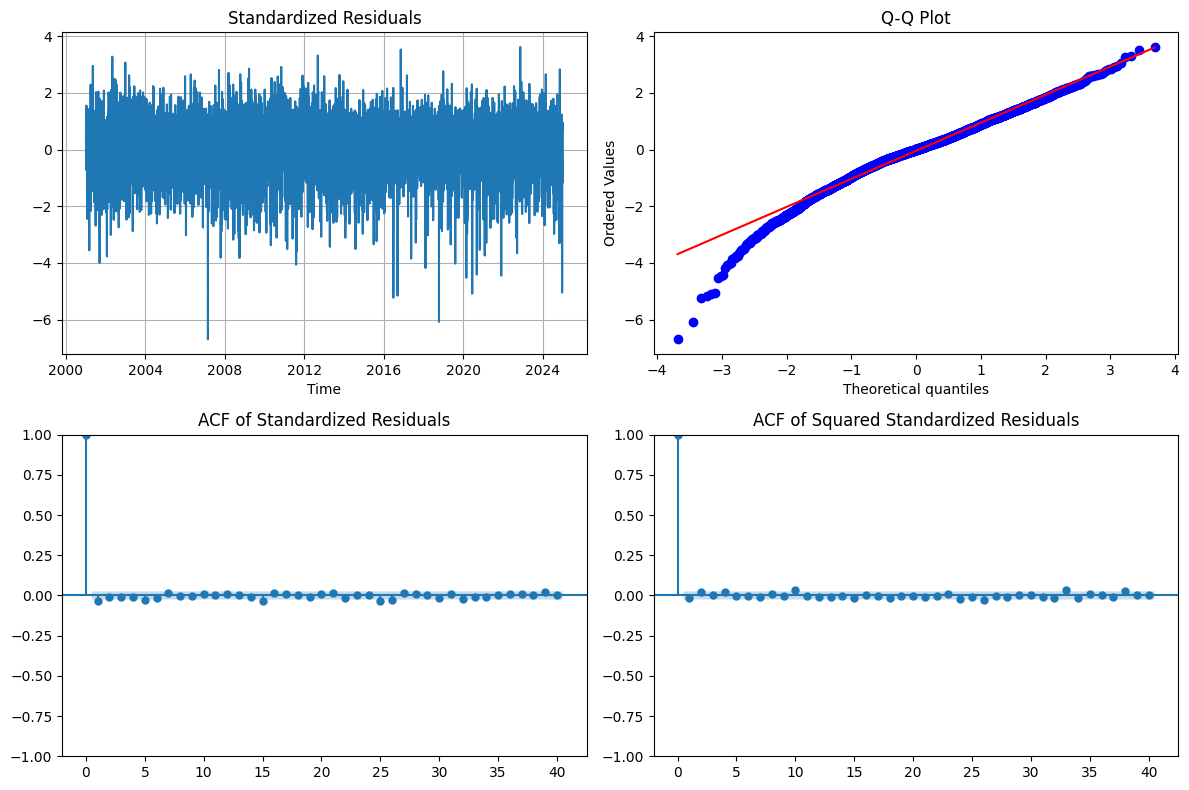

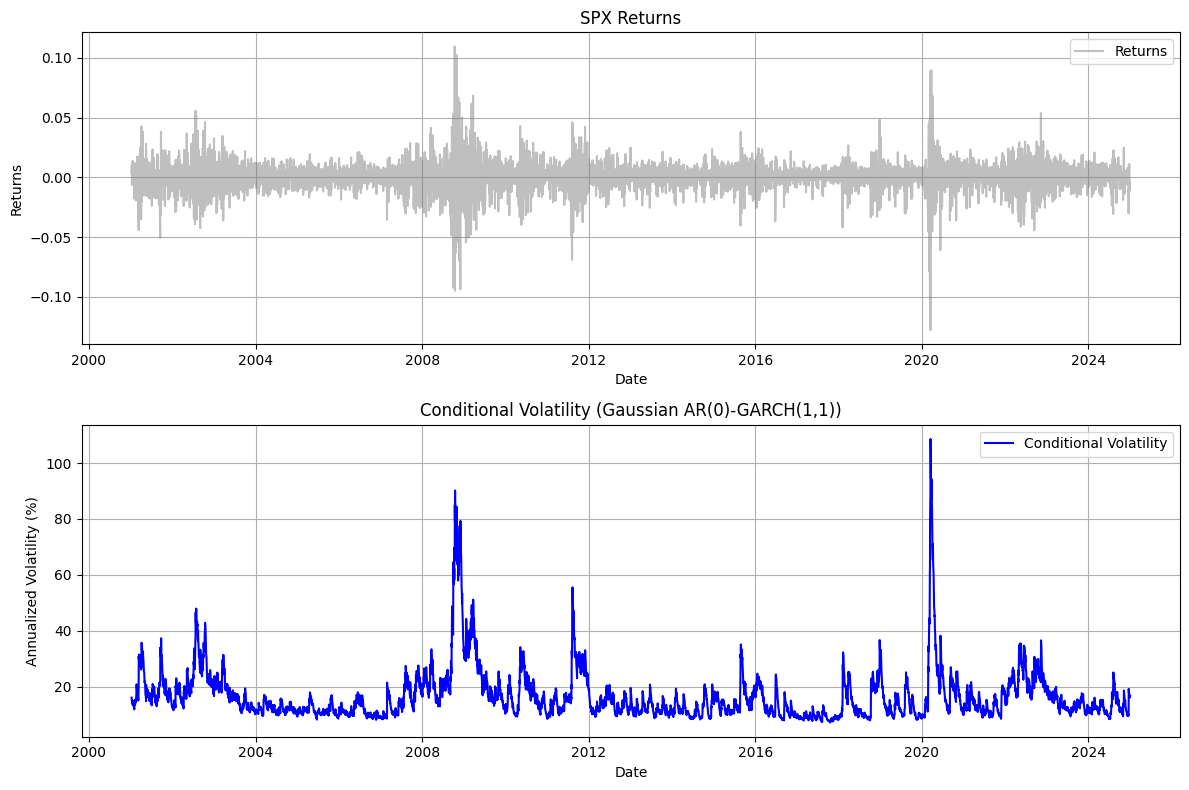


Ljung-Box Test Results:

For residuals:
Lag 10: statistic = 18.7753, p-value = 0.0046
Lag 20: statistic = 31.1208, p-value = 0.0130
Lag 30: statistic = 46.9089, p-value = 0.0072

For absolute residuals:
Lag 10: statistic = 34.9340, p-value = 0.0000
Lag 20: statistic = 40.7904, p-value = 0.0006
Lag 30: statistic = 52.9515, p-value = 0.0014

For squared residuals:
Lag 10: statistic = 14.9607, p-value = 0.0206
Lag 20: statistic = 18.7392, p-value = 0.2824
Lag 30: statistic = 29.4604, p-value = 0.2906

Jarque-Bera Test for Normality:
Statistic = 999.2982
P-value = 0.0000

Descriptive Statistics of Standardized Residuals:
Mean: -0.0446
Std Dev: 0.9989
Skewness: -0.5327
Kurtosis: 1.6854


In [18]:
# Fit GARCH(1,1) models with different distributions
models = {
    'Gaussian AR(0)': arch_model(spx_returns*scale_factor, mean='AR', lags=0, vol='GARCH', p=1, q=1, dist='normal', rescale=False), 
    'Student-t AR(0)': arch_model(spx_returns*scale_factor, mean='AR', lags=0, vol='GARCH', p=1, q=1, dist='studentst', rescale=False),
    'Skewed Student-t AR(0)': arch_model(spx_returns*scale_factor, mean='AR', lags=0, vol='GARCH', p=1, q=1, dist='skewstudent', rescale=False),
    'GED AR(0)': arch_model(spx_returns*scale_factor, mean='AR', lags=0, vol='GARCH', p=1, q=1, dist='ged', rescale=False)
}


# Fit models and store results
results = {}
for name, model in models.items():
    results[name] = model.fit(disp='off')
    print(f"\n{name} GARCH(1,1) Model Results:")
    print("="*80)
    print(results[name].summary())

# Plot returns and conditional volatilities
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('GARCH(1,1) Models with Different Distributions (AR(0))')

# Filter for only AR(0) models
ar0_results = {name: result for name, result in results.items() if 'AR(0)' in name}

for (name, result), ax in zip(ar0_results.items(), axes.ravel()):
    ax.plot(result.conditional_volatility/scale_factor*np.sqrt(252)*100, label=name)
    ax.set_title(name)
    ax.set_xlabel('Date')
    ax.set_ylabel('Conditional Volatility (annualized in percent)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig('ar0_garch11_spx_volatility.pdf')
plt.show()

# Compare model fits using information criteria
ic_df = pd.DataFrame({
    'AIC': [result.aic for result in results.values()],
    'BIC': [result.bic for result in results.values()],
    'Log-Likelihood': [result.loglikelihood for result in results.values()]
}, index=results.keys())

# Get standardized residuals from Gaussian AR(0)-GARCH(1,1) model
std_resid = results['Gaussian AR(0)'].std_resid

# Create figure with 4 subplots for diagnostic plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized residuals
ax1.plot(std_resid)
ax1.set_title('Standardized Residuals')
ax1.set_xlabel('Time')
ax1.grid(True)

# Plot 2: QQ plot
stats.probplot(std_resid, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot')

# Plot 3: ACF of standardized residuals
import statsmodels.api as smapi
smapi.graphics.tsa.plot_acf(std_resid, lags=40, ax=ax3)
ax3.set_title('ACF of Standardized Residuals')

# Plot 4: ACF of squared standardized residuals
smapi.graphics.tsa.plot_acf(std_resid**2, lags=40, ax=ax4)
ax4.set_title('ACF of Squared Standardized Residuals')

plt.tight_layout()
plt.savefig('ar0_garch11_diagnostics.pdf')
plt.show()

# Plot returns and conditional volatility for Gaussian AR(0)-GARCH(1,1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot returns
ax1.plot(spx_returns, color='gray', alpha=0.5, label='Returns')
ax1.set_title('SPX Returns')
ax1.set_xlabel('Date')
ax1.set_ylabel('Returns')
ax1.grid(True)
ax1.legend()

# Plot conditional volatility
cond_vol = results['Gaussian AR(0)'].conditional_volatility
ax2.plot(cond_vol/scale_factor*np.sqrt(252)*100, color='blue', label='Conditional Volatility')
ax2.set_title('Conditional Volatility (Gaussian AR(0)-GARCH(1,1))')
ax2.set_xlabel('Date')
ax2.set_ylabel('Annualized Volatility (%)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig('ar0_garch11_gaussian_spx_volatility.pdf')
plt.show()


# Perform Ljung-Box test on standardized residuals and squared standardized residuals
import statsmodels.stats.diagnostic as sm
lags = [10, 20, 30]
print("\nLjung-Box Test Results:")
print("\nFor residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(std_resid, lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-4)
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

print("\nFor absolute residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(np.abs(std_resid), lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-4) # 
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

print("\nFor squared residuals:")
for lag in lags:
    lb_test = sm.acorr_ljungbox(std_resid**2, lags=[lag], return_df=False)
    adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-4) # 
    print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

# Perform Jarque-Bera test for normality
jb_stat, jb_pvalue = stats.jarque_bera(std_resid)
print("\nJarque-Bera Test for Normality:")
print("="*80)
print(f"Statistic = {jb_stat:.4f}")
print(f"P-value = {jb_pvalue:.4f}")

# Calculate and print descriptive statistics
print("\nDescriptive Statistics of Standardized Residuals:")
print("="*80)
print(f"Mean: {np.mean(std_resid):.4f}")
print(f"Std Dev: {np.std(std_resid):.4f}")
print(f"Skewness: {stats.skew(std_resid):.4f}")
print(f"Kurtosis: {stats.kurtosis(std_resid):.4f}")




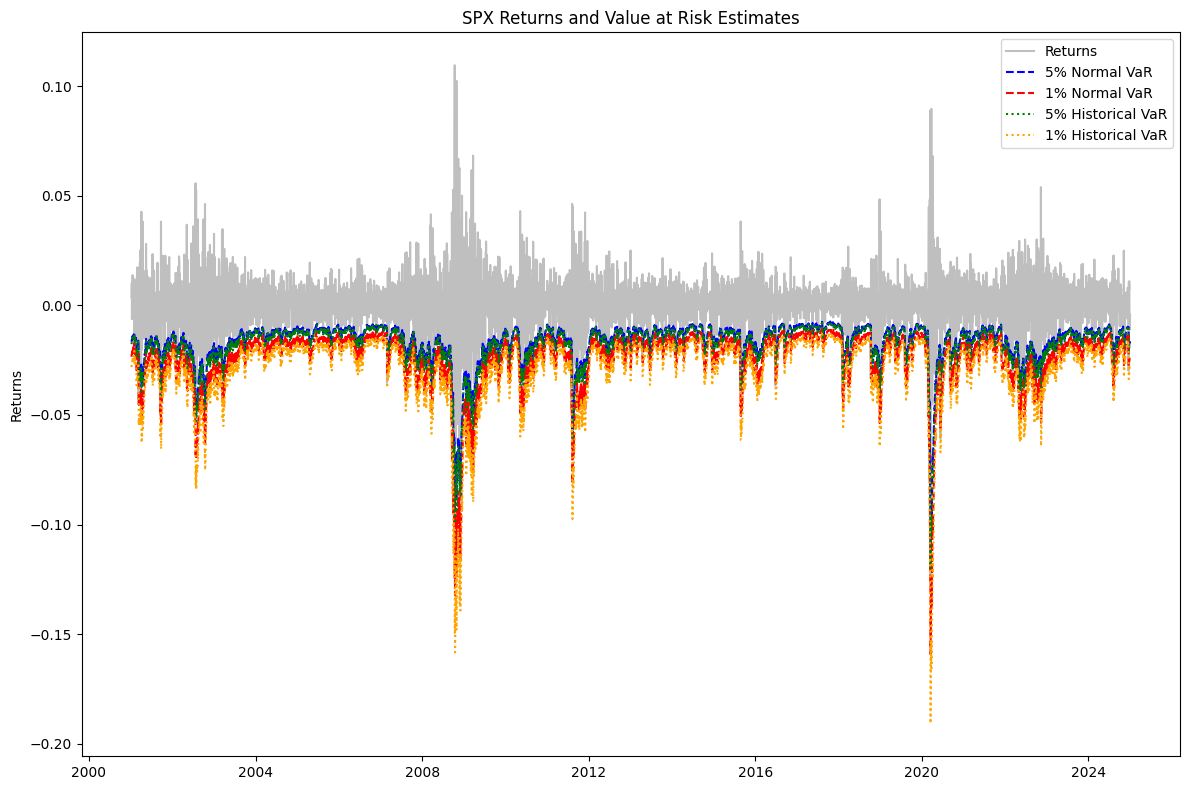


VaR Violations (%):
Normal 5% VaR: 5.34%
Normal 1% VaR: 2.07%
Historical 5% VaR: 4.46%
Historical 1% VaR: 0.96%


In [19]:
# Fit AR(0)-GARCH(1,1) model with Gaussian innovations
model = arch_model(spx_returns*scale_factor, mean='AR', lags=0, vol='GARCH', p=1, q=1, rescale=False)
results = model.fit(disp='off')

# Get standardized residuals and conditional volatility
std_resid = results.std_resid
cond_vol = results.conditional_volatility/scale_factor

# Calculate VaR assuming normal innovations
from scipy.stats import norm
norm_var_5 = norm.ppf(0.05) * cond_vol
norm_var_1 = norm.ppf(0.01) * cond_vol

# Calculate VaR using historical simulation (sampling from standardized residuals)
hist_var_5 = np.percentile(std_resid, 5) * cond_vol 
hist_var_1 = np.percentile(std_resid, 1) * cond_vol

# Plot returns and VaR estimates
plt.figure(figsize=(12, 8))

# Plot returns
plt.plot(spx_returns, color='gray', alpha=0.5, label='Returns')

# Plot VaR estimates
plt.plot(norm_var_5, color='blue', label='5% Normal VaR', linestyle='--')
plt.plot(norm_var_1, color='red', label='1% Normal VaR', linestyle='--')
plt.plot(hist_var_5, color='green', label='5% Historical VaR', linestyle=':')
plt.plot(hist_var_1, color='orange', label='1% Historical VaR', linestyle=':')

plt.title('SPX Returns and Value at Risk Estimates')
plt.ylabel('Returns')
plt.legend()
plt.tight_layout()
plt.savefig('var_estimates_garch11.pdf')
plt.show()

# Calculate VaR violations
norm_violations_5 = np.mean(spx_returns < norm_var_5) * 100
norm_violations_1 = np.mean(spx_returns < norm_var_1) * 100
hist_violations_5 = np.mean(spx_returns < hist_var_5) * 100
hist_violations_1 = np.mean(spx_returns < hist_var_1) * 100

print("\nVaR Violations (%):")
print("="*50)
print(f"Normal 5% VaR: {norm_violations_5:.2f}%")
print(f"Normal 1% VaR: {norm_violations_1:.2f}%")
print(f"Historical 5% VaR: {hist_violations_5:.2f}%")
print(f"Historical 1% VaR: {hist_violations_1:.2f}%")



Fitting GJR-GARCH model...
                         AR - GJR-GARCH Model Results                         
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -8098.84
Distribution:                  Normal   AIC:                           16207.7
Method:            Maximum Likelihood   BIC:                           16241.2
                                        No. Observations:                 6032
Date:                Fri, Feb 14 2025   Df Residuals:                     6031
Time:                        12:50:04   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const          0.0250  1.060e-

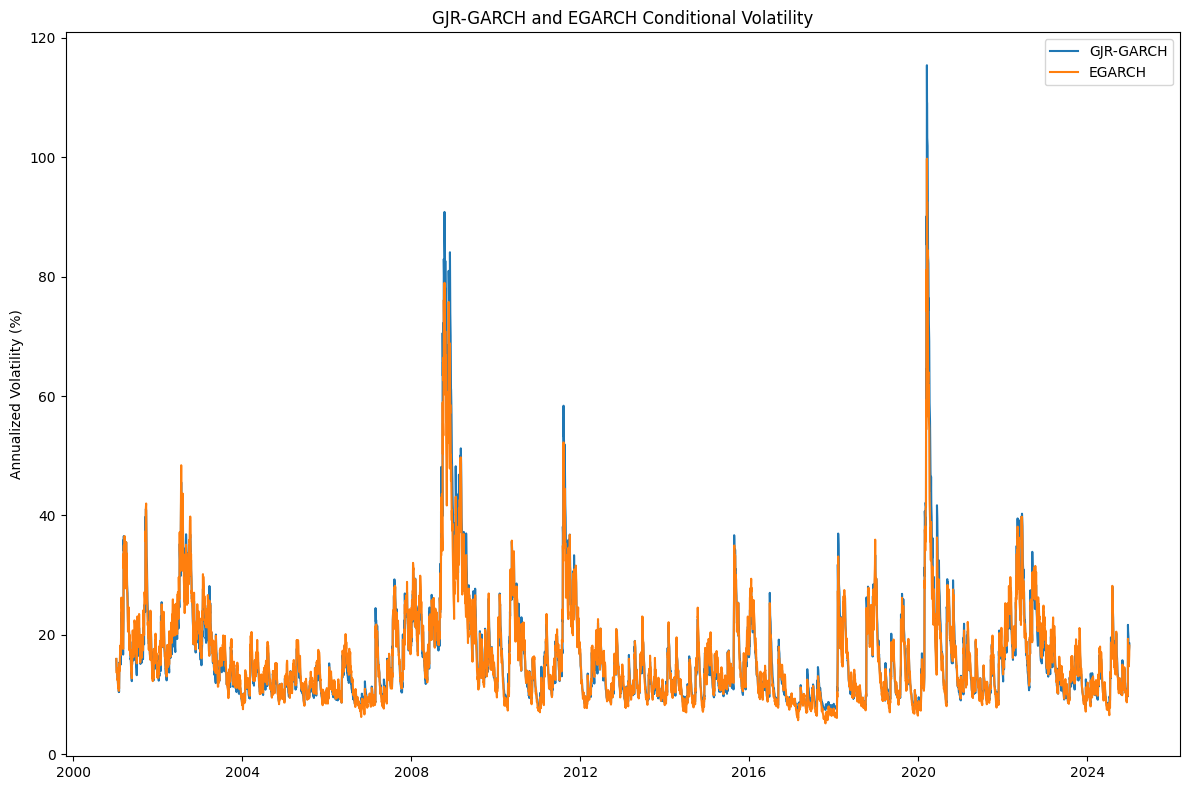


Model Performance:
Model           Log-Likelihood  AIC             BIC            
--------------------------------------------------------------------------------
GJR-GARCH       -8098.84        16207.67        16241.20       
EGARCH          -8088.84        16187.68        16221.20       


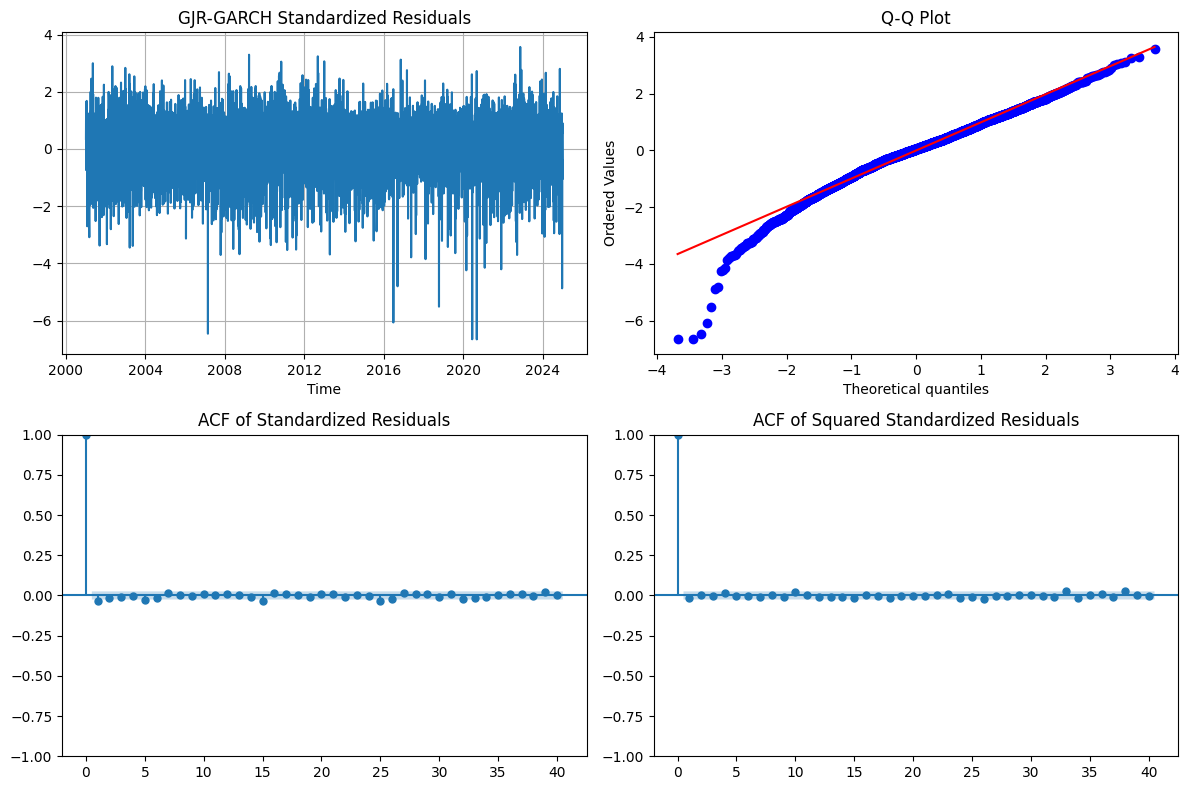

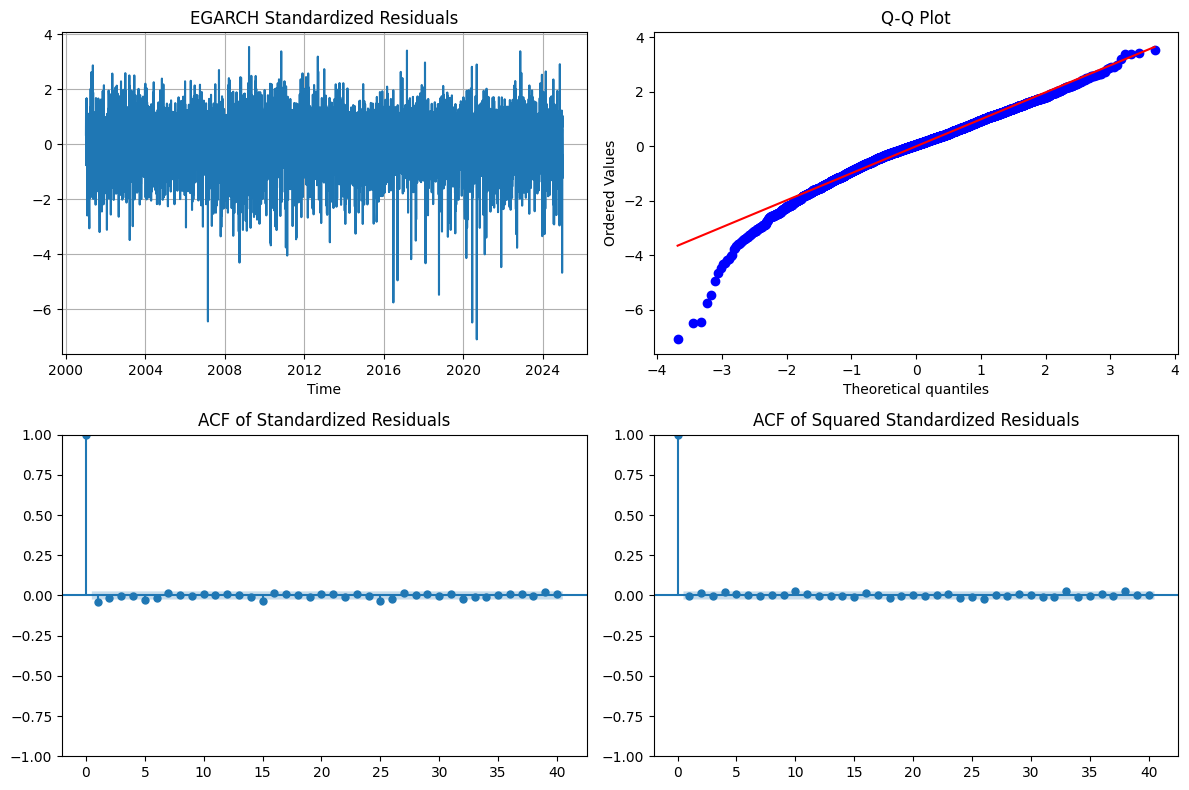

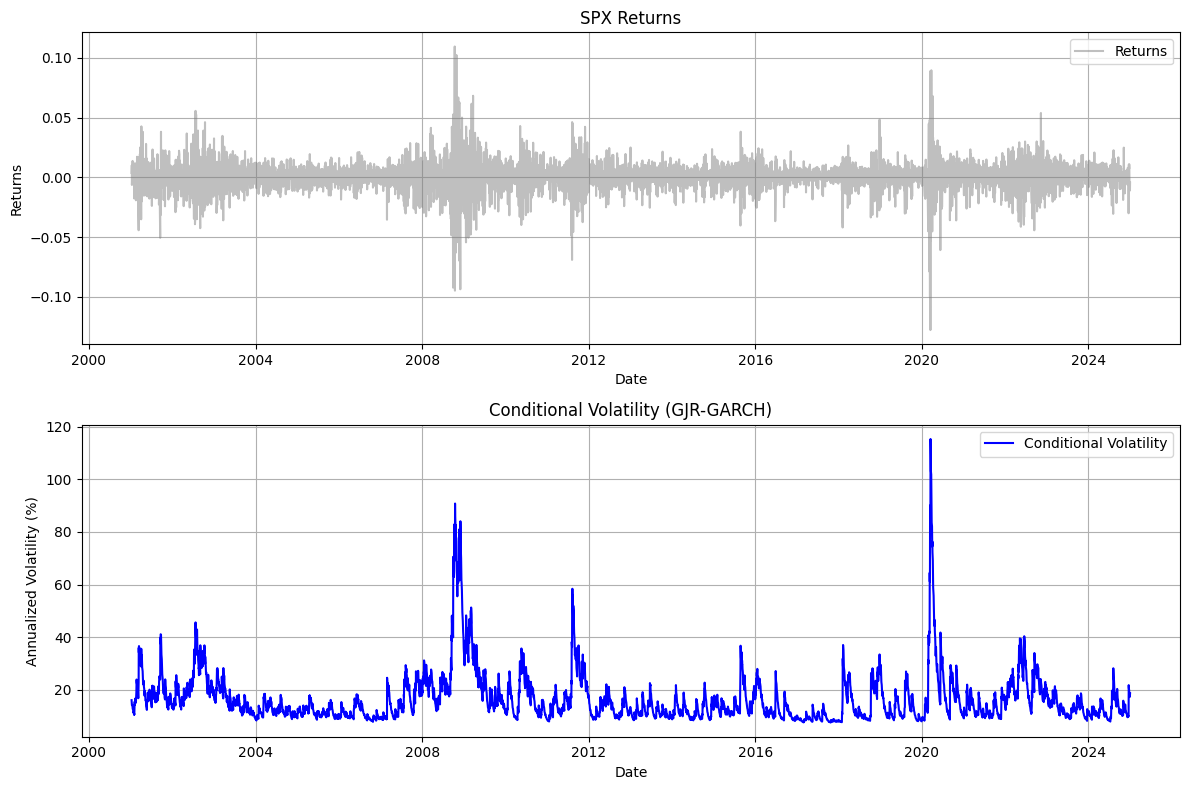

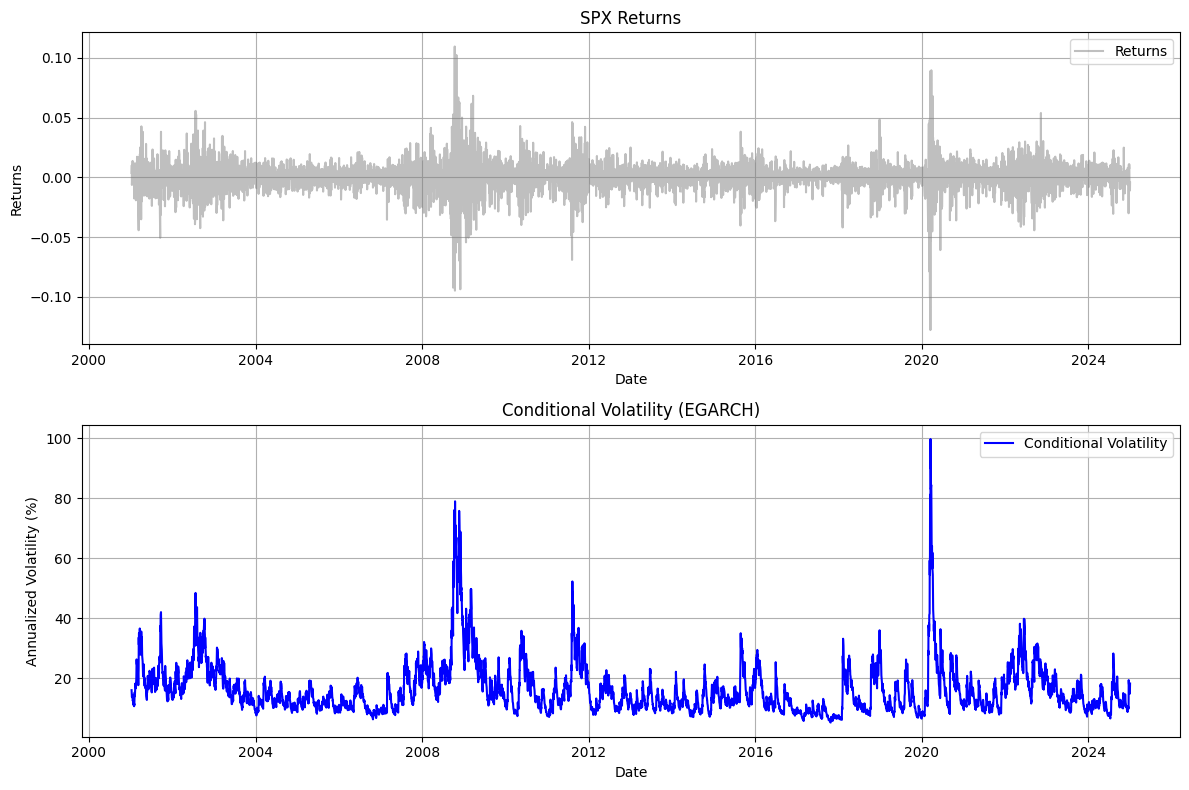


GJR-GARCH Test Results:

Ljung-Box Test Results:

For residuals:
Lag 10: statistic = 17.9899, p-value = 0.0063
Lag 20: statistic = 29.5340, p-value = 0.0206
Lag 30: statistic = 45.2689, p-value = 0.0110

For absolute residuals:
Lag 10: statistic = 30.2964, p-value = 0.0000
Lag 20: statistic = 36.5761, p-value = 0.0024
Lag 30: statistic = 48.2583, p-value = 0.0050

For squared residuals:
Lag 10: statistic = 6.9770, p-value = 0.3230
Lag 20: statistic = 11.5335, p-value = 0.7754
Lag 30: statistic = 19.0714, p-value = 0.8334

Jarque-Bera Test for Normality:
Statistic = 1310.8366
P-value = 0.0000

Descriptive Statistics of Standardized Residuals:
Mean: -0.0043
Std Dev: 1.0000
Skewness: -0.5886
Kurtosis: 1.9569

EGARCH Test Results:

Ljung-Box Test Results:

For residuals:
Lag 10: statistic = 20.7524, p-value = 0.0020
Lag 20: statistic = 31.6880, p-value = 0.0110
Lag 30: statistic = 47.1022, p-value = 0.0068

For absolute residuals:
Lag 10: statistic = 32.3091, p-value = 0.0000
Lag 20: stat

In [20]:
# Fit GJR-GARCH model with AR(0) mean
model_gjr = arch_model(spx_returns*scale_factor, mean='AR', lags=0, vol='GARCH', p=1, o=1, q=1, rescale=False)
model_egarch = arch_model(spx_returns*scale_factor, mean='AR', lags=0, vol='EGARCH', p=1, o=1, q=1, rescale=False)

# Fit models and store results
print("\nFitting GJR-GARCH model...")
try:
    results_gjr = model_gjr.fit(disp='off')
    print(results_gjr.summary())
except:
    print("Failed to fit GJR-GARCH model")

print("\nFitting EGARCH model...")    
try:
    results_egarch = model_egarch.fit(disp='off')
    print(results_egarch.summary())
except:
    print("Failed to fit EGARCH model")

# Plot conditional volatilities
plt.figure(figsize=(12, 8))
plt.plot(results_gjr.conditional_volatility/scale_factor*np.sqrt(252)*100, label='GJR-GARCH')
plt.plot(results_egarch.conditional_volatility/scale_factor*np.sqrt(252)*100, label='EGARCH')
plt.title('GJR-GARCH and EGARCH Conditional Volatility')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.tight_layout()
plt.savefig('conditional_volatility_asymmetric.pdf')
plt.show()

# Print model performance metrics
print("\nModel Performance:")
print("="*80)
print(f"{'Model':<15} {'Log-Likelihood':<15} {'AIC':<15} {'BIC':<15}")
print("-"*80)
print(f"{'GJR-GARCH':<15} {results_gjr.loglikelihood:<15.2f} {results_gjr.aic:<15.2f} {results_gjr.bic:<15.2f}")
print(f"{'EGARCH':<15} {results_egarch.loglikelihood:<15.2f} {results_egarch.aic:<15.2f} {results_egarch.bic:<15.2f}")

# Get standardized residuals for both models
std_resid_gjr = results_gjr.std_resid
std_resid_egarch = results_egarch.std_resid

# Create diagnostic plots for both models
for model_name, std_resid in [('GJR-GARCH', std_resid_gjr), ('EGARCH', std_resid_egarch)]:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
    
    # Plot 1: Standardized residuals
    ax1.plot(std_resid)
    ax1.set_title(f'{model_name} Standardized Residuals')
    ax1.set_xlabel('Time')
    ax1.grid(True)

    # Plot 2: QQ plot
    stats.probplot(std_resid, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot')

    # Plot 3: ACF of standardized residuals
    smapi.graphics.tsa.plot_acf(std_resid, lags=40, ax=ax3)
    ax3.set_title('ACF of Standardized Residuals')

    # Plot 4: ACF of squared standardized residuals
    smapi.graphics.tsa.plot_acf(std_resid**2, lags=40, ax=ax4)
    ax4.set_title('ACF of Squared Standardized Residuals')

    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_diagnostics.pdf')
    plt.show()

# Plot returns and conditional volatility for both models
for model_name, results in [('GJR-GARCH', results_gjr), ('EGARCH', results_egarch)]:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot returns
    ax1.plot(spx_returns, color='gray', alpha=0.5, label='Returns')
    ax1.set_title('SPX Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Returns')
    ax1.grid(True)
    ax1.legend()

    # Plot conditional volatility
    cond_vol = results.conditional_volatility
    ax2.plot(cond_vol/scale_factor*np.sqrt(252)*100, color='blue', label='Conditional Volatility')
    ax2.set_title(f'Conditional Volatility ({model_name})')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Annualized Volatility (%)')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_spx_volatility.pdf')
    plt.show()

# Perform statistical tests for both models
for model_name, std_resid in [('GJR-GARCH', std_resid_gjr), ('EGARCH', std_resid_egarch)]:
    print(f"\n{model_name} Test Results:")
    print("="*80)
    
    # Ljung-Box tests
    lags = [10, 20, 30]
    print("\nLjung-Box Test Results:")
    print("\nFor residuals:")
    for lag in lags:
        lb_test = sm.acorr_ljungbox(std_resid, lags=[lag], return_df=False)
        adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-4)
        print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

    print("\nFor absolute residuals:")
    for lag in lags:
        lb_test = sm.acorr_ljungbox(np.abs(std_resid), lags=[lag], return_df=False)
        adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-4)
        print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

    print("\nFor squared residuals:")
    for lag in lags:
        lb_test = sm.acorr_ljungbox(std_resid**2, lags=[lag], return_df=False)
        adj_pvalue = 1 - stats.chi2.cdf(lb_test['lb_stat'].values[0], df=lag-4)
        print(f"Lag {lag}: statistic = {lb_test['lb_stat'].values[0]:.4f}, p-value = {adj_pvalue:.4f}")

    # Jarque-Bera test
    jb_stat, jb_pvalue = stats.jarque_bera(std_resid)
    print("\nJarque-Bera Test for Normality:")
    print("="*50)
    print(f"Statistic = {jb_stat:.4f}")
    print(f"P-value = {jb_pvalue:.4f}")

    # Descriptive statistics
    print("\nDescriptive Statistics of Standardized Residuals:")
    print("="*50)
    print(f"Mean: {np.mean(std_resid):.4f}")
    print(f"Std Dev: {np.std(std_resid):.4f}")
    print(f"Skewness: {stats.skew(std_resid):.4f}")
    print(f"Kurtosis: {stats.kurtosis(std_resid):.4f}")